# Supplementary File X: Line Profile Plotting of Tubulin Staining
for ``Four-Fold Expansion Microscopy of Cultured Cells"
by Corban Swain, Sapna Sinha, and Ed Boyden

*Jupyter Notebook containing ImageJ commands and Python script for !!UPDATE!!*

## 1. Setting Up Repository and Opening the Notebook
1. You will need to install and set up the following software before continuing:
   - [ ] [**git** https://git-scm.com/](https://git-scm.com/)
   - [ ] [**mamba** https://mamba.readthedocs.io](https://mamba.readthedocs.io/en/latest/installation/mamba-installation.html)
   - [ ] [**Fiji (ImageJ)** https://imagej.net/software/fiji/downloads](https://imagej.net/software/fiji/downloads)
         (version 1.54p was used)
2. Clone the
   [**ExM-Demo-Figures** repository (https://github.com/CorbanSwain/ExM-Demo-Figures)](https://github.com/CorbanSwain/ExM-Demo-Figures)
   into a directory (e.g. `~/ExM-Demo-Figures`) on your computer. Then initialize and update the submodules.
   ```
   cd ~
   git clone https://github.com/CorbanSwain/ExM-Demo-Figures ~/ExM-Demo-Figures
   git submodule update --init
   ```
4. Set up the Python environment according to the environment configuration provided in the repository.
   ```
   cd ~/ExM-Demo-Figures/envs/
   mamba create -f exm-demo-fig-py3.12-env.yml
   ```
5. Then run JupyterLab and open this notebook via the JupyterLab interface.
   ```
   cd ~/ExM-Demo-Figures/source
   mamba activate exm-demo-fig-py3.12-env 
   jupyter lab supplementary_file_03-nuc-area.ipynb
   ```

## 2. Registration and Measurement of Images in Fiji
Follow these instructions to process the images for nuclei area quantification.

!!UPDATE!!


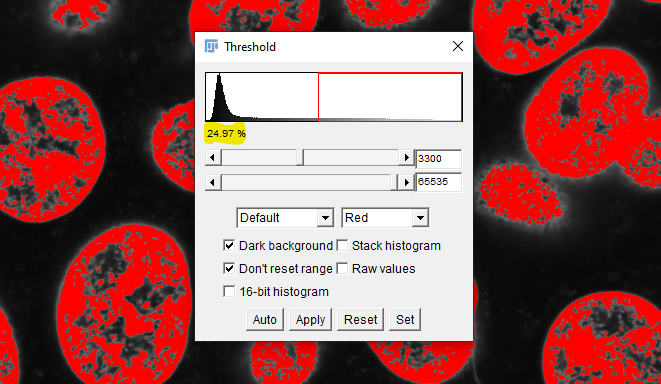

## 3. Analysis, Plotting of Nuclei Sizes with Python
Run the following cells to process the extracted results data.

### 3.1 Package Imports

In [1]:
# 3.1.1 base and metaprogramming imports
import os
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

# 3.1.2 ipynb-specific imports
try:
    import ipynbname
except Exception as e:
    warnings.warn(f'`ipynbname` module import failed with error: {e!r}')
    ipynbname = None
    
if ipynbname is not None:
    _file = ipynbname.path()
else:
    # manually set the full path to the current notebook below if `ipynbname` 
    # import fails
    _file = ''

# 3.1.3 key path variables and management
source_dir = os.path.split(_file)[0]
repo_dir = os.path.abspath(os.path.join(source_dir, '..'))
data_dir = os.path.join(repo_dir, 'data')
figure_dir = os.path.join(repo_dir, 'figures')
if source_dir not in sys.path:
    sys.path.append(source_dir)

print('Imports done.')

Imports done.


### 3.2 Plotting Defaults

In [54]:
# 3.2.1 load custom fonts, if available
custom_fonts = [
    'C:\\Windows\\Fonts\\Linotype - HelveticaLTPro-Black.otf',
    'C:\\Windows\\Fonts\\Linotype - HelveticaLTPro-Bold.otf',
    'C:\\Windows\\Fonts\\Linotype - HelveticaLTPro-Roman.otf',
    'C:\\Windows\\Fonts\\Linotype - HelveticaLTPro-Oblique.otf']
for font_path in custom_fonts:
    if os.path.exists(font_path):
        print(f'Adding font: "{os.path.split(font_path)[-1]}" to mpl.')
        mpl.font_manager.fontManager.addfont(font_path)

# 3.2.2 set plotting style
sns.set_style(
    'ticks',
    {'font.sans-serif': [
        'Helvetica LT Pro', 'Helvetica', 'Arial', 'sans-serif'],
     'mathtext.fontset': ['cm',],
     'axes.linewidth': 2})

# 3.2.3 set axis and figure defaults
axes_lw = 1.25
mpl.rcParams['axes.linewidth'] = axes_lw
mpl.rcParams['xtick.major.width'] = axes_lw
mpl.rcParams['xtick.minor.width'] = axes_lw
mpl.rcParams['ytick.major.width'] = axes_lw
mpl.rcParams['ytick.minor.width'] = axes_lw

mpl.rcParams['axes.facecolor'] = 'none'

mpl.rcParams['figure.frameon'] = False
mpl.rcParams['figure.facecolor'] = 'none'
mpl.rcParams['figure.edgecolor'] = 'none'

print('Plotting defaults set; done.')

Adding font: "Linotype - HelveticaLTPro-Black.otf" to mpl.
Adding font: "Linotype - HelveticaLTPro-Bold.otf" to mpl.
Adding font: "Linotype - HelveticaLTPro-Roman.otf" to mpl.
Adding font: "Linotype - HelveticaLTPro-Oblique.otf" to mpl.
Plotting defaults set; done.


### 3.3 Filepaths and Other Parameter Inputs

In [23]:
# 3.3.1 filepath names
# Edit these fields to match the files you wish to analyze.
line_profile_dname = 'line-profile-analysis'
pre_exm_fname = 'PRE.csv'
post_exm_fname = 'POST.csv'

figure_name = 'line_profiles'  # output figure name

# 3.3.2 table keys
fiji_location_key = 'Distance_(microns)'
px_intensity_key = 'Gray_Value'
norm_intensity_key = 'norm_intensity'
bio_loc_key = 'biological_dist_microns'
physical_loc_key = 'physical_dist_microns'
sample_id_key = 'sample_id'

# 3.3.3 good region list (extracted from Fiji, noted down in `overlay-scales.txt`)
pre_exm_pixels_per_micron = 24.9917
post_exm_pixels_per_micron = 5.8891

print('Parameters set; done.')
print(f'Expansion Ratio = {pre_exm_pixels_per_micron / post_exm_pixels_per_micron:.2f}x')

Parameters set; done.
Expansion Ratio = 4.24x


### 3.4 Loading and Processing Data Tables

In [94]:
# 3.4.1 generate full paths to files
line_profile_dir = os.path.join(data_dir, line_profile_dname)
pre_exm_path = os.path.join(line_profile_dir, pre_exm_fname)
post_exm_path = os.path.join(line_profile_dir, post_exm_fname)

# 3.4.2 load `.csv` files into pandas `DataFrame`s
pre_exm_df = pd.read_csv(pre_exm_path)
post_exm_df = pd.read_csv(post_exm_path)

# ensure length of dataframes are equal
assert len(pre_exm_df) == len(post_exm_df)

simple_index = np.arange(len(pre_exm_df))

pre_exm_df[bio_loc_key] = simple_index / pre_exm_pixels_per_micron
pre_exm_df[physical_loc_key] = pre_exm_df[bio_loc_key]
pre_exm_df[sample_id_key] = 'normal'

post_exm_df[bio_loc_key] = pre_exm_df[bio_loc_key]
post_exm_df[physical_loc_key] = simple_index / post_exm_pixels_per_micron
post_exm_df[sample_id_key] = 'expanded'

def normalize_intensity(df, key, baseline_len=10):
    # get first `baseline_len` rows of data as baseline
    baseline = df[key].iloc[:baseline_len].mean()
    df[norm_intensity_key] = df[key] - baseline
    df[norm_intensity_key] = df[norm_intensity_key] / df[norm_intensity_key].max()
    return df

normalize_intensity(pre_exm_df, px_intensity_key)
normalize_intensity(post_exm_df, px_intensity_key)

# append dataframes to one another
line_profile_df = pd.concat([pre_exm_df, post_exm_df])
line_profile_df[sample_id_key] = line_profile_df[sample_id_key].astype('category')

def print_df_info(df, name):
    print(f'\n{"v"*25} {name} Data Frame: {"v"*25}')
    df.info(memory_usage=False)
    print()
    print(df.head(2))

print_df_info(pre_exm_df, 'PRE')
print_df_info(post_exm_df, 'POST')
print_df_info(line_profile_df, 'Line Profile')

print('\nData tables loaded and processed; done.')


vvvvvvvvvvvvvvvvvvvvvvvvv PRE Data Frame: vvvvvvvvvvvvvvvvvvvvvvvvv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 644 entries, 0 to 643
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Distance_(microns)       644 non-null    float64
 1   Gray_Value               644 non-null    float64
 2   biological_dist_microns  644 non-null    float64
 3   physical_dist_microns    644 non-null    float64
 4   sample_id                644 non-null    object 
 5   norm_intensity           644 non-null    float64
dtypes: float64(5), object(1)
   Distance_(microns)  Gray_Value  biological_dist_microns  \
0              0.0000     160.000                 0.000000   
1              0.0402     171.238                 0.040013   

   physical_dist_microns sample_id  norm_intensity  
0               0.000000    normal       -0.013542  
1               0.040013    normal       -0.006595  

vvvvvvvvvvvvvvvvvv

### 3.7 Create and Save Figure

Figure generated and saved; done.


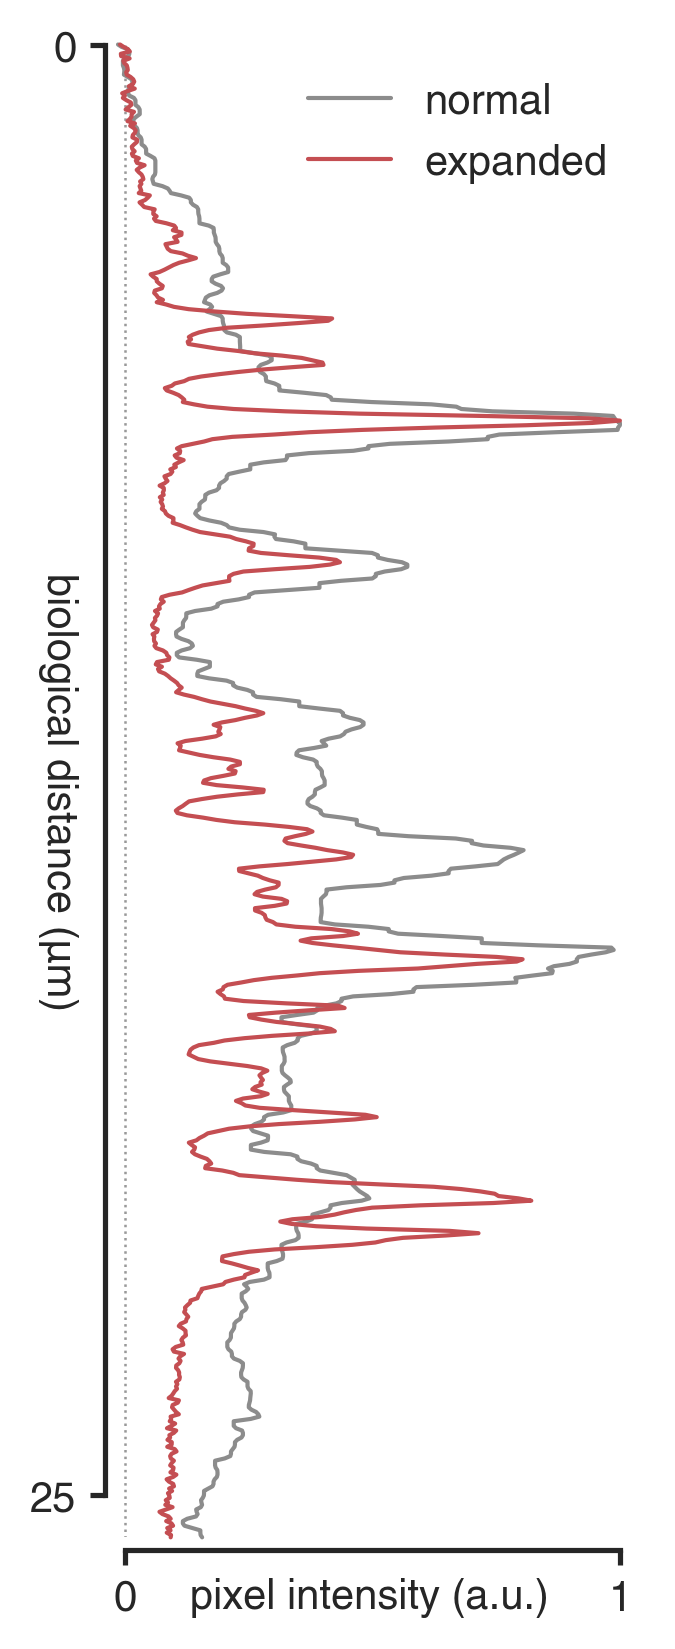

In [107]:
# 3.7.1 generate main figure object
fig = plt.figure(
    figsize=(2.35, 5.6),
    dpi=300)

# 3.7.2 set color palettes
palette_p = sns.color_palette(
    [sns.color_palette('pastel')[7],
     sns.color_palette('pastel')[3]])
palette_n = sns.color_palette(
    [sns.color_palette('deep')[7],
     sns.color_palette('deep')[3]])

# 3.7.3 use seaborn to create line plot
ax = sns.lineplot(
    line_profile_df,
    x=norm_intensity_key,
    y=bio_loc_key,
    hue=sample_id_key,
    palette=palette_n,
    hue_order=['normal', 'expanded'],
    linewidth=1,
    dashes=False,
    orient='y',
    markers=False,
    clip_on=False,
    legend=True,)

ymin = 0
ymax = line_profile_df[bio_loc_key].max()

ax.vlines(
    x=0,
    ymax=ymax,
    ymin=ymin,
    color='k',
    alpha=0.4,
    linewidth=0.6,
    linestyle=':',
    zorder=-1,)

ax.invert_yaxis()

sns.despine(right=True, top=True)
ax.set_ylim(ymax, ymin)
ax.spines['left'].set_bounds(0, 25)
ax.spines['left'].set_position(('outward', -3))
ax.set_yticks([0, 25])
ax.spines['bottom'].set_bounds(0, 1)
ax.spines['bottom'].set_position(('outward', 3))
ax.set_xticks([0, 1])
ax.set_xticklabels(['0', '1'])
ax.set_ylabel('biological distance (\u00b5m)',
              labelpad=-2, rotation=-90)
ax.set_xlabel('pixel intensity (a.u.)',
              labelpad=-10)

leg = ax.get_legend()
leg.set_title('')
sns.move_legend(ax, loc='best', frameon=False)


# 3.7.9 helper function for saving figure to pdf
def save_figures(
    filename=None, 
    figs=None, 
    dpi=200, 
    fmt='pdf', 
    directory=None,
    add_filename_timestamp=True, 
    stamp_kwargs=None):
    from matplotlib.backends.backend_pdf import PdfPages

    if filename is None:
        filename = 'all_figures'

    if add_filename_timestamp:
        filename = filename + '_' + time.strftime('%y%m%d-%H%M')

    if figs is None:
        figs = [plt.figure(n) for n in plt.get_fignums()]
    else:
        try:
            _ = iter(figs)
        except TypeError:
            figs = [figs, ]

    if stamp_kwargs:
        [stamp_fig(fig, **stamp_kwargs) for fig in figs]

    directory = 'figures' if directory is None else directory
    try:
        os.mkdir(directory)
    except FileExistsError:
        pass

    file_path = os.path.join(directory, filename)
    if fmt == 'pdf':
        file_path += '.pdf'
        with PdfPages(file_path) as pp:
            for fig in figs:
                fig.savefig(pp, format='pdf', dpi=dpi)
    else:
        for i, fig in enumerate(figs):
            fig.savefig('%s_%d.%s' % (file_path, i, fmt), format=fmt, dpi=dpi)

# 3.7.10 perform final layout of plot
plt.tight_layout()

# 3.7.11 export figure to pdf
save_figures(
    filename=figure_name,
    add_filename_timestamp=False,
    directory=figure_dir)

print('Figure generated and saved; done.')

## 4 Notebook Conversion 
This notebook can be converted to a `.pdf` via the following [**pandoc** (https://pandoc.org/)](https://pandoc.org/) 
command:

*for Unix-style command line:*
```bash
pandoc -o "supplementary_file_03-nuc-area.pdf" \  
    --pdf-engine=xelatex --highlight-style tango \
    -V geometry:landscape \
    -V geometry:top=0.75in,bottom=0.75in,left=1in,right=2in
    supplementary_file_03-nuc-area.ipynb
```

*for Windows Command Prompt:*
```
pandoc -o "supplementary_file_03-nuc-area.pdf" ^
    --pdf-engine=xelatex --highlight-style tango ^
    -V geometry:landscape ^
    -V geometry:top=0.75in,bottom=0.75in,left=1in,right=2in ^
    supplementary_file_03-nuc-area.ipynb
    
```